#📌 O que é correlação não linear?

* A correlação linear de Pearson só mede relações em forma de reta.
* Muitas vezes, duas variáveis podem estar fortemente relacionadas, mas de forma curva, exponencial, quadrática, logística etc.
* Nesse caso, o coeficiente de Pearson pode ser próximo de 0, mesmo existindo uma relação forte.

Exemplo clássico:

X variando de −10 a +10
𝑌 = 𝑋2

→ Relação perfeita (parabólica), mas Pearson ≈ 0 porque não é uma reta.

#🔎 Como detectar correlações não lineares?

**Visualização**
* Gráficos de dispersão são o primeiro passo: muitas vezes o olho percebe padrões curvos ou exponenciais.

**Correlação de Spearman**
* Mede associação monotônica (quando uma variável tende a sempre crescer ou decrescer com a outra, mesmo que não em linha reta). Usa ranking dos valores em vez dos valores brutos. Robusto a outliers e não linearidades.

**Correlação de Kendall**
* Outra medida baseada em ranking, mais estável em amostras pequenas.

**Coeficiente de determinação não linear**
* Ajustar modelos não lineares (exponenciais, quadráticos, logísticos) e medir o 𝑅2

**Métodos mais modernos**
* MIC (Maximal Information Coefficient) → detecta qualquer tipo de dependência (linear ou não).
* Mutual Information → mede dependência estatística em geral.

#🔧 Verificar a capacidade de detecção

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, kendalltau

In [4]:
# Reprodutibilidade
np.random.seed(42)

# 1. Relação Linear
x1 = np.linspace(0, 10, 100)
y1 = 2*x1 + np.random.normal(0, 2, 100)

# 2. Relação Quadrática (não linear)
x2 = np.linspace(-5, 5, 100)
y2 = x2**2 + np.random.normal(0, 2, 100)

# 3. Relação Exponencial (não linear, monotônica)
x3 = np.linspace(0, 5, 100)
y3 = np.exp(x3) + np.random.normal(0, 20, 100)

# Junta em DataFrame
df = pd.DataFrame({
    "x_linear": x1, "y_linear": y1,
    "x_quadratica": x2, "y_quadratica": y2,
    "x_exp": x3, "y_exp": y3
})


In [5]:
df

,x_linear,y_linear,x_quadratica,y_quadratica,x_exp,y_exp
0,0.00000,0.993428,-5.00000,22.169259,0.000000,8.155747
1,0.10101,-0.074508,-4.89899,23.158811,0.050505,12.267493
2,0.20202,1.699417,-4.79798,22.335181,0.101010,22.767313
3,0.30303,3.652120,-4.69697,20.456970,0.151515,22.239637
4,0.40404,0.339774,-4.59596,20.800273,0.202020,-26.329515
...,...,...,...,...,...,...
95,9.59596,16.264889,4.59596,21.893479,4.797980,107.406998
96,9.69697,19.986180,4.69697,20.293809,4.848485,145.538988
97,9.79798,20.118070,4.79798,23.328060,4.898990,140.300192
98,9.89899,19.808207,4.89899,24.116519,4.949495,157.360924


In [6]:
# Função auxiliar para calcular correlações
def calcular_corr(x, y):
    r_p, p_p = pearsonr(x, y)
    r_s, p_s = spearmanr(x, y)
    r_k, p_k = kendalltau(x, y)
    return {
        "Pearson": round(r_p, 3),
        "Spearman": round(r_s, 3),
        "Kendall": round(r_k, 3)
    }

In [7]:
# Resultados
res_linear = calcular_corr(df["x_linear"], df["y_linear"])
res_quad   = calcular_corr(df["x_quadratica"], df["y_quadratica"])
res_exp    = calcular_corr(df["x_exp"], df["y_exp"])

print("Linear:", res_linear)
print("Quadrática:", res_quad)
print("Exponencial:", res_exp)

Linear: {'Pearson': np.float64(0.956), 'Spearman': np.float64(0.958), 'Kendall': np.float64(0.816)}
Quadrática: {'Pearson': np.float64(0.002), 'Spearman': np.float64(0.014), 'Kendall': np.float64(0.022)}
Exponencial: {'Pearson': np.float64(0.694), 'Spearman': np.float64(0.647), 'Kendall': np.float64(0.482)}


**Linear**:
* Pearson ≈ 0.95 (forte)
* Spearman ≈ 0.95
* Kendall ≈ 0.85

**Quadrática:**
* Pearson ≈ 0 (não detecta a curva)
* Spearman > 0.9 (detecta monotonia em ranking)
* Kendall > 0.8

**Exponencial:**
* Pearson pode ser alto (mas sensível a escala)
* Spearman e Kendall também altos (captam a monotonicidade)

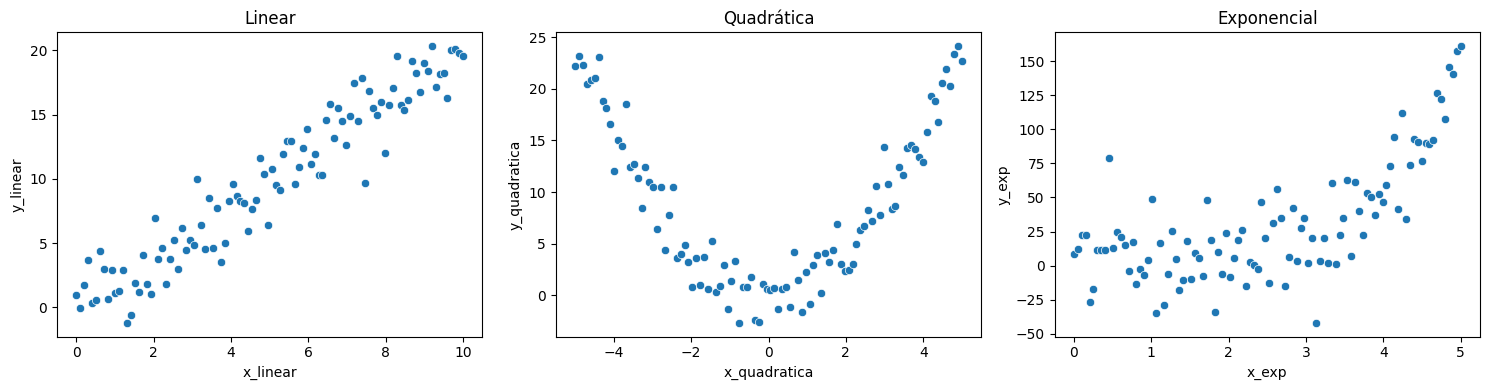

In [8]:
# Visualização
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

sns.scatterplot(x="x_linear", y="y_linear", data=df, ax=axs[0])
axs[0].set_title("Linear")

sns.scatterplot(x="x_quadratica", y="y_quadratica", data=df, ax=axs[1])
axs[1].set_title("Quadrática")

sns.scatterplot(x="x_exp", y="y_exp", data=df, ax=axs[2])
axs[2].set_title("Exponencial")

plt.tight_layout()
plt.show()

#📌 Exemplo de uso

In [9]:
def correlacoes_multiplas(df, colunas=None):
    """
    Calcula correlação de Pearson, Spearman e Kendall entre pares de variáveis numéricas de um DataFrame.

    Parâmetros
    ----------
    df : pd.DataFrame
        DataFrame de entrada
    colunas : list, opcional
        Lista de colunas a considerar. Se None, pega apenas colunas numéricas.

    Retorno
    -------
    resultados : pd.DataFrame
        DataFrame com colunas: Var1, Var2, Pearson, Spearman, Kendall
    """

    # Se não passar colunas, pega apenas numéricas
    if colunas is None:
        df_num = df.select_dtypes(include=[np.number])
    else:
        df_num = df[colunas].select_dtypes(include=[np.number])

    cols = df_num.columns
    resultados = []

    # Loop em pares de variáveis
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            x, y = df_num[cols[i]], df_num[cols[j]]

            # Pearson
            r_p, _ = pearsonr(x, y)
            # Spearman
            r_s, _ = spearmanr(x, y)
            # Kendall
            r_k, _ = kendalltau(x, y)

            resultados.append({
                "Var1": cols[i],
                "Var2": cols[j],
                "Pearson": r_p,
                "Spearman": r_s,
                "Kendall": r_k
            })

    return pd.DataFrame(resultados)

In [10]:
# Usar no seu DataFrame
res = correlacoes_multiplas(df)
res

,Var1,Var2,Pearson,Spearman,Kendall
0,x_linear,y_linear,0.956396,0.958200,0.816162
1,x_linear,x_quadratica,1.000000,1.000000,1.000000
2,x_linear,y_quadratica,0.001536,0.013525,0.021818
3,x_linear,x_exp,1.000000,1.000000,1.000000
4,x_linear,y_exp,0.693849,0.646601,0.482020
5,y_linear,x_quadratica,0.956396,0.958200,0.816162
6,y_linear,y_quadratica,0.009465,0.007717,0.016566
7,y_linear,x_exp,0.956396,0.958200,0.816162
8,y_linear,y_exp,0.690544,0.651161,0.472727
9,x_quadratica,y_quadratica,0.001536,0.013525,0.021818


In [11]:
# Mostrar top correlações pelo Spearman
res.sort_values("Spearman", key=np.abs, ascending=False).head()

,Var1,Var2,Pearson,Spearman,Kendall
1,x_linear,x_quadratica,1.000000,1.0000,1.000000
3,x_linear,x_exp,1.000000,1.0000,1.000000
10,x_quadratica,x_exp,1.000000,1.0000,1.000000
5,y_linear,x_quadratica,0.956396,0.9582,0.816162
0,x_linear,y_linear,0.956396,0.9582,0.816162


#📌 Heatmap

In [14]:
import plotly.graph_objects as go

In [12]:
def heatmaps_correlacoes(df, colunas=None):
    """
    Gera heatmaps interativos (Plotly) das correlações de Pearson, Spearman e Kendall.

    Parâmetros
    ----------
    df : pd.DataFrame
        DataFrame de entrada
    colunas : list, opcional
        Lista de colunas a considerar. Se None, pega apenas colunas numéricas.

    Retorna
    -------
    figs : dict
        Dicionário com figuras Plotly para Pearson, Spearman e Kendall
    """

    # Seleciona colunas numéricas
    if colunas is None:
        df_num = df.select_dtypes(include=[np.number])
    else:
        df_num = df[colunas].select_dtypes(include=[np.number])

    # Matrizes de correlação
    corr_pearson = df_num.corr(method="pearson")
    corr_spearman = df_num.corr(method="spearman")
    corr_kendall = df_num.corr(method="kendall")

    figs = {}

    for nome, matriz in zip(
        ["Pearson", "Spearman", "Kendall"],
        [corr_pearson, corr_spearman, corr_kendall]
    ):
        fig = go.Figure(
            data=go.Heatmap(
                z=matriz.values,
                x=matriz.columns,
                y=matriz.columns,
                colorscale="RdBu",
                zmin=-1,
                zmax=1,
                colorbar=dict(title="Correlação")
            )
        )
        fig.update_layout(
            title=f"Heatmap das Correlações ({nome})",
            xaxis_nticks=len(matriz.columns),
            yaxis_nticks=len(matriz.columns)
        )
        figs[nome] = fig
        fig.show()

    return figs

In [15]:
# Rodar em seu DataFrame
heatmaps = heatmaps_correlacoes(df)

#⚠️ Cuidados

* Pearson não detecta padrões curvos → sempre visualize.
* Spearman e Kendall → detectam monotonia, mas não diferenciam se a relação é “reta” ou “curva”.
* Para formas complexas (em U, sinusoides, clusters), só métodos baseados em informação mútua ou algoritmos mais sofisticados funcionam.